# Lab 1: Building RelWeights

This lab turns the matrix story in `Defining RelWeights` into an executable overlay workflow. The goal is to start from two polygon layers, build an incidence matrix $B$, and then construct the contextual similarity graph

$$
R = B B^{\top} - \operatorname{diag}(B B^{\top}).
$$

The core construction below follows the same logic as the public RelWeights repository and, in particular, the `tab2relweights` workflow implemented in [`relweights.py`](https://github.com/shamilkhedgikar/RelWeights/blob/main/relweights.py). The sample overlay data used here is a small packaged subset derived from the local `RelWeights` data folder so that the notebook can run quickly end to end.

## Learning goals

By the end of this lab, you should be able to:

- explain the difference between an incidence matrix $B$, a contextual similarity matrix $R$, and a Laplacian $L_R$
- build binary and area-share incidence matrices from two overlaid polygon layers
- see how the same districts can be connected by inherited supports even when they are not immediate geographic neighbors
- generate a support-level surface, aggregate it to districts, and compare geographic and relational Laplacian responses
- interpret linear and quadratic Laplacian calculations and inspect the eigenvalue spectrum of the resulting operators

## Imports and configuration

In [1]:
from __future__ import annotations

import base64
import json
from pathlib import Path
from tempfile import TemporaryDirectory
import zipfile

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from matplotlib.lines import Line2D
from shapely.geometry import LineString

In [2]:
AREA_CRS = "EPSG:32644"
GEOGRAPHIC_CONTIGUITY = "queen"
SAMPLE_ZIP_CANDIDATES = [
    Path("data/lab1_relweights_sample.zip"),
    Path("lab/book/content/02-lab-1-building-relweights/data/lab1_relweights_sample.zip"),
]

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

## Helper functions

In [3]:
def resolve_sample_zip(candidates: list[Path]) -> Path:
    """Return the first existing sample zip path."""

    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find lab1_relweights_sample.zip. "
        "Checked: " + ", ".join(str(p) for p in candidates)
    )


def interactive_output_dir_from_zip(zip_path: Path) -> Path:
    """Place standalone map HTML next to the notebook content folder."""

    output_dir = zip_path.parent.parent / "interactive"
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def load_packaged_layers(zip_path: Path) -> tuple[TemporaryDirectory, gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """Extract the packaged sample zip and return the two GeoDataFrames."""

    tmpdir = TemporaryDirectory()
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmpdir.name)

    districts = gpd.read_file(Path(tmpdir.name) / "districts.geojson")
    supports = gpd.read_file(Path(tmpdir.name) / "subbasins.geojson")

    districts = districts[~districts.geometry.isna() & ~districts.geometry.is_empty].copy()
    supports = supports[~supports.geometry.isna() & ~supports.geometry.is_empty].copy()

    return tmpdir, districts, supports


def build_incidence_matrices(
    rel_layer: gpd.GeoDataFrame,
    inh_layer: gpd.GeoDataFrame,
    rel_id: str,
    inh_id: str,
    area_crs: str = AREA_CRS,
) -> tuple[pd.DataFrame, pd.DataFrame, gpd.GeoDataFrame]:
    """Construct binary and area-share incidence matrices from overlay intersections.

    The binary matrix records whether an overlap exists.
    The area-share matrix records what share of each analysis polygon is covered
    by each inherited support polygon.
    """

    rel = rel_layer[[rel_id, "geometry"]].copy()
    inh = inh_layer[[inh_id, "geometry"]].copy().to_crs(rel.crs)

    overlay = gpd.overlay(rel, inh, how="intersection", keep_geom_type=False)
    overlay_projected = overlay.to_crs(area_crs)
    rel_projected = rel.to_crs(area_crs)

    rel_area = rel_projected.set_index(rel_id).geometry.area
    overlay["overlap_area"] = overlay_projected.geometry.area
    overlay["area_share"] = overlay["overlap_area"] / overlay[rel_id].map(rel_area)

    binary = pd.crosstab(overlay[rel_id], overlay[inh_id])
    binary = binary.reindex(index=rel_layer[rel_id], columns=inh_layer[inh_id], fill_value=0)
    binary = (binary > 0).astype(int)

    area = (
        overlay.pivot_table(
            index=rel_id,
            columns=inh_id,
            values="area_share",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(index=rel_layer[rel_id], columns=inh_layer[inh_id], fill_value=0.0)
        .astype(float)
    )

    return binary, area, overlay


def relweights_from_incidence(incidence: pd.DataFrame, row_standardize: bool = False) -> pd.DataFrame:
    """Compute R = B B' with a zero diagonal from an incidence matrix."""

    B = incidence.to_numpy(dtype=float)
    R = B @ B.T
    np.fill_diagonal(R, 0.0)

    if row_standardize:
        row_sums = R.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        R = R / row_sums

    return pd.DataFrame(R, index=incidence.index, columns=incidence.index)


def laplacian_from_weights(weights_df: pd.DataFrame) -> pd.DataFrame:
    """Construct D - W from a square weight matrix."""

    W = weights_df.to_numpy(dtype=float)
    D = np.diag(W.sum(axis=1))
    L = D - W
    return pd.DataFrame(L, index=weights_df.index, columns=weights_df.columns)


def build_geographic_contiguity_weights(
    layer: gpd.GeoDataFrame,
    id_col: str,
    mode: str = GEOGRAPHIC_CONTIGUITY,
) -> pd.DataFrame:
    """Construct a binary queen- or rook-contiguity matrix on the analysis layer."""

    mode = mode.lower()
    if mode not in {"queen", "rook"}:
        raise ValueError("mode must be either 'queen' or 'rook'")

    ids = layer[id_col].tolist()
    n = len(layer)
    W = np.zeros((n, n), dtype=float)
    geoms = layer.geometry.reset_index(drop=True)

    for i in range(n):
        for j in range(i + 1, n):
            shared_boundary = geoms.iloc[i].boundary.intersection(geoms.iloc[j].boundary)
            is_neighbor = (not shared_boundary.is_empty) and (
                mode == "queen" or shared_boundary.length > 0
            )
            if is_neighbor:
                W[i, j] = 1.0
                W[j, i] = 1.0

    return pd.DataFrame(W, index=ids, columns=ids)


def build_centroid_nodes(
    layer: gpd.GeoDataFrame,
    id_col: str,
    label_cols: list[str] | None = None,
    area_crs: str = AREA_CRS,
) -> gpd.GeoDataFrame:
    """Return centroid nodes in the original layer CRS for graph-style plotting."""

    label_cols = label_cols or []
    keep_cols = list(dict.fromkeys([id_col, *label_cols, "geometry"]))
    projected = layer[keep_cols].copy().to_crs(area_crs)
    centroids = gpd.GeoSeries(projected.geometry.centroid, crs=area_crs)
    nodes = projected.drop(columns="geometry").copy()
    nodes = gpd.GeoDataFrame(nodes, geometry=centroids, crs=area_crs)
    return nodes.to_crs(layer.crs)


def build_centroid_edges(
    layer: gpd.GeoDataFrame,
    id_col: str,
    weights_df: pd.DataFrame,
    edge_type: str,
    area_crs: str = AREA_CRS,
) -> gpd.GeoDataFrame:
    """Connect centroid pairs wherever the weight matrix has a positive entry."""

    projected = layer[[id_col, "geometry"]].copy().to_crs(area_crs)
    centroids = gpd.GeoSeries(projected.geometry.centroid, crs=area_crs)
    centroid_lookup = dict(zip(projected[id_col], centroids))
    edge_records: list[dict[str, object]] = []

    for i, source_id in enumerate(weights_df.index):
        for j in range(i + 1, len(weights_df.columns)):
            target_id = weights_df.columns[j]
            weight = float(weights_df.iat[i, j])
            if weight <= 0:
                continue
            edge_records.append(
                {
                    "source_id": source_id,
                    "target_id": target_id,
                    "weight": weight,
                    "edge_type": edge_type,
                    "geometry": LineString([centroid_lookup[source_id], centroid_lookup[target_id]]),
                }
            )

    if not edge_records:
        empty_edges = gpd.GeoDataFrame(
            {"source_id": [], "target_id": [], "weight": [], "edge_type": []},
            geometry=gpd.GeoSeries([], crs=layer.crs),
            crs=layer.crs,
        )
        return empty_edges

    edges = gpd.GeoDataFrame(edge_records, geometry="geometry", crs=area_crs)
    return edges.to_crs(layer.crs)


def build_neighbor_lookup(weights_df: pd.DataFrame) -> dict[str, list[str]]:
    """Return neighbor ids for every district under a binary support graph."""

    binary = (weights_df > 0).astype(int)
    return {
        str(source_id): [str(target_id) for target_id, value in row.items() if value > 0]
        for source_id, row in binary.iterrows()
    }


def build_hover_edge_geojson(
    centroid_nodes: gpd.GeoDataFrame,
    id_col: str,
    weights_df: pd.DataFrame,
) -> dict[str, dict[str, object]]:
    """Precompute hover-time centroid edges for each focal district."""

    centroid_lookup = {
        str(row[id_col]): row.geometry
        for _, row in centroid_nodes[[id_col, "geometry"]].iterrows()
    }
    edge_lookup: dict[str, dict[str, object]] = {}

    for source_id in weights_df.index:
        source_key = str(source_id)
        features: list[dict[str, object]] = []
        for target_id, value in weights_df.loc[source_id].items():
            if float(value) <= 0:
                continue
            target_key = str(target_id)
            line = LineString([centroid_lookup[source_key], centroid_lookup[target_key]])
            features.append(
                {
                    "type": "Feature",
                    "properties": {
                        "source_id": source_key,
                        "target_id": target_key,
                        "weight": float(value),
                    },
                    "geometry": line.__geo_interface__,
                }
            )
        edge_lookup[source_key] = {"type": "FeatureCollection", "features": features}

    return edge_lookup


def add_centroid_markers(
    map_obj: folium.Map,
    centroid_nodes: gpd.GeoDataFrame,
    id_col: str,
    label_col: str,
    layer_name: str = "Centroid nodes",
) -> folium.FeatureGroup:
    """Add centroid markers as a toggleable map layer."""

    group = folium.FeatureGroup(name=layer_name, show=True)
    for _, row in centroid_nodes.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=3,
            color="#111827",
            fill=True,
            fill_color="#111827",
            fill_opacity=0.9,
            weight=1,
            tooltip=f"{row[id_col]}: {row[label_col]}",
        ).add_to(group)
    group.add_to(map_obj)
    return group


def add_neighbor_hover_behavior(
    map_obj: folium.Map,
    geojson_layer: folium.GeoJson,
    id_property: str,
    neighbor_map: dict[str, list[str]],
    edge_map: dict[str, dict[str, object]],
    base_style: dict[str, object],
    hover_style: dict[str, object],
    neighbor_style: dict[str, object],
    edge_style: dict[str, object],
) -> None:
    """Highlight hovered districts, their neighbors, and the corresponding centroid edges."""

    script = f"""
    setTimeout(function() {{
        var neighborMap = {json.dumps(neighbor_map)};
        var edgeMap = {json.dumps(edge_map)};
        var baseStyle = {json.dumps(base_style)};
        var hoverStyle = {json.dumps(hover_style)};
        var neighborStyle = {json.dumps(neighbor_style)};
        var edgeStyle = {json.dumps(edge_style)};
        var mapObject = {map_obj.get_name()};
        var geoLayer = {geojson_layer.get_name()};
        var edgeLayer = L.geoJSON(null, {{
            style: function() {{
                return edgeStyle;
            }}
        }}).addTo(mapObject);
        var layerIndex = {{}};

        function resetNeighborExplorer() {{
            edgeLayer.clearLayers();
            geoLayer.eachLayer(function(otherLayer) {{
                otherLayer.setStyle(baseStyle);
            }});
        }}

        geoLayer.eachLayer(function(layer) {{
            var featureId = String(layer.feature.properties["{id_property}"]);
            layerIndex[featureId] = layer;
            layer.on({{
                mouseover: function() {{
                    resetNeighborExplorer();
                    layer.setStyle(hoverStyle);
                    (neighborMap[featureId] || []).forEach(function(neighborId) {{
                        if (layerIndex[neighborId]) {{
                            layerIndex[neighborId].setStyle(neighborStyle);
                            if (layerIndex[neighborId].bringToFront) {{
                                layerIndex[neighborId].bringToFront();
                            }}
                        }}
                    }});
                    if (edgeMap[featureId]) {{
                        edgeLayer.addData(edgeMap[featureId]);
                    }}
                    if (layer.bringToFront) {{
                        layer.bringToFront();
                    }}
                }},
                mouseout: function() {{
                    resetNeighborExplorer();
                }}
            }});
        }});
        resetNeighborExplorer();
    }}, 0);
    """

    map_obj.get_root().script.add_child(folium.Element(script))


def make_connectivity_map(
    districts: gpd.GeoDataFrame,
    centroid_nodes: gpd.GeoDataFrame,
    geographic_edges: gpd.GeoDataFrame,
    rel_only_edges: gpd.GeoDataFrame,
    id_col: str,
    label_col: str,
    geographic_label: str,
) -> folium.Map:
    """Create a layer-toggle map for full queen/rook and RelWeights-only graphs."""

    study_centroid = districts.geometry.union_all().centroid
    center = [
        float(study_centroid.y),
        float(study_centroid.x),
    ]
    graph_map = folium.Map(location=center, zoom_start=9, tiles="CartoDB positron")

    district_layer = folium.FeatureGroup(name="District polygons", show=True)
    folium.GeoJson(
        districts[["ac_id", "AC_NAME", "DIST_NAME", "geometry"]].to_json(),
        name="District polygons",
        style_function=lambda _feature: {
            "color": "#9ca3af",
            "weight": 1.0,
            "fillColor": "#e5e7eb",
            "fillOpacity": 0.25,
        },
        tooltip=folium.GeoJsonTooltip(fields=["ac_id", "AC_NAME", "DIST_NAME"]),
    ).add_to(district_layer)
    district_layer.add_to(graph_map)

    add_centroid_markers(graph_map, centroid_nodes, id_col=id_col, label_col=label_col)

    if not geographic_edges.empty:
        folium.GeoJson(
            geographic_edges.to_json(),
            name=f"{geographic_label} edges",
            style_function=lambda _feature: {
                "color": "#475569",
                "weight": 2.0,
                "opacity": 0.7,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=["source_id", "target_id"],
                aliases=["Source", "Target"],
            ),
        ).add_to(graph_map)

    if not rel_only_edges.empty:
        folium.GeoJson(
            rel_only_edges.to_json(),
            name="RelWeights-only inherited ties",
            style_function=lambda _feature: {
                "color": "#ea580c",
                "weight": 2.6,
                "opacity": 0.8,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=["source_id", "target_id", "weight"],
                aliases=["Source", "Target", "Shared supports"],
            ),
        ).add_to(graph_map)

    folium.LayerControl(collapsed=False).add_to(graph_map)
    return graph_map


def make_hover_neighbor_map(
    districts: gpd.GeoDataFrame,
    centroid_nodes: gpd.GeoDataFrame,
    weights_df: pd.DataFrame,
    id_col: str,
    label_col: str,
    title: str,
    neighbor_color: str,
    edge_color: str,
) -> folium.Map:
    """Create a hover-based neighborhood explorer for one support graph."""

    study_centroid = districts.geometry.union_all().centroid
    center = [
        float(study_centroid.y),
        float(study_centroid.x),
    ]
    explorer = folium.Map(location=center, zoom_start=9, tiles="CartoDB positron")
    base_style = {
        "color": "#6b7280",
        "weight": 1.0,
        "fillColor": "#f3f4f6",
        "fillOpacity": 0.45,
    }
    hover_style = {
        "color": "#111827",
        "weight": 2.5,
        "fillColor": "#111827",
        "fillOpacity": 0.2,
    }
    neighbor_style = {
        "color": neighbor_color,
        "weight": 2.2,
        "fillColor": neighbor_color,
        "fillOpacity": 0.35,
    }

    geojson_layer = folium.GeoJson(
        districts[[id_col, "AC_NAME", "DIST_NAME", "geometry"]].to_json(),
        name=title,
        style_function=lambda _feature: base_style.copy(),
        tooltip=folium.GeoJsonTooltip(fields=[id_col, "AC_NAME", "DIST_NAME"]),
    )
    geojson_layer.add_to(explorer)
    add_centroid_markers(explorer, centroid_nodes, id_col=id_col, label_col=label_col)

    neighbor_map = build_neighbor_lookup(weights_df)
    edge_map = build_hover_edge_geojson(centroid_nodes, id_col=id_col, weights_df=weights_df)
    add_neighbor_hover_behavior(
        map_obj=explorer,
        geojson_layer=geojson_layer,
        id_property=id_col,
        neighbor_map=neighbor_map,
        edge_map=edge_map,
        base_style=base_style,
        hover_style=hover_style,
        neighbor_style=neighbor_style,
        edge_style={
            "color": edge_color,
            "weight": 3.0,
            "opacity": 0.9,
        },
    )

    instructions = f"""
    <div style="
        position: fixed;
        bottom: 20px;
        left: 20px;
        z-index: 9999;
        background: rgba(255, 255, 255, 0.95);
        border: 1px solid #d1d5db;
        border-radius: 6px;
        padding: 10px 12px;
        font-size: 12px;
        line-height: 1.35;
    ">
        <strong>{title}</strong><br>
        Hover on one district to reveal its first-order neighbors and centroid edges.
    </div>
    """
    explorer.get_root().html.add_child(folium.Element(instructions))
    return explorer


def save_and_embed_folium_map(
    map_obj: folium.Map,
    output_path: Path,
    height: int = 620,
) -> None:
    """Save a Folium map to standalone HTML and embed it back without file:// iframes."""

    output_path.parent.mkdir(parents=True, exist_ok=True)
    map_obj.save(str(output_path))
    rel_path = output_path.as_posix()
    data_uri = "data:text/html;base64," + base64.b64encode(output_path.read_bytes()).decode("ascii")
    display(
        HTML(
            f"""
            <div style="margin: 0.5rem 0 1rem 0;">
              <iframe
                src="{data_uri}"
                width="100%"
                height="{height}"
                style="border: 1px solid #d1d5db; border-radius: 8px; background: white;"
              ></iframe>
              <div style="margin-top: 0.5rem; font-size: 0.92rem;">
                <a href="{rel_path}" target="_blank" rel="noopener noreferrer">
                  Open standalone interactive map
                </a>
              </div>
            </div>
            """
        )
    )


def centered_laplacian_energy(values: np.ndarray, laplacian_df: pd.DataFrame) -> float:
    """Return z' L z for the centered signal z."""

    z = values - values.mean()
    L = laplacian_df.to_numpy(dtype=float)
    return float(z.T @ L @ z)


def build_support_effects(supports: gpd.GeoDataFrame, area_crs: str = AREA_CRS) -> pd.DataFrame:
    """Assign a deterministic scalar effect to each support polygon."""

    supports_proj = supports[["support_id", "geometry"]].copy().to_crs(area_crs)
    centroid_x = supports_proj.geometry.centroid.x
    centroid_y = supports_proj.geometry.centroid.y
    x_std = (centroid_x - centroid_x.mean()) / centroid_x.std(ddof=0)
    y_std = (centroid_y - centroid_y.mean()) / centroid_y.std(ddof=0)
    order = np.linspace(-1.0, 1.0, len(supports_proj))

    effects = 0.9 * y_std - 0.55 * x_std + 0.35 * np.sin(np.pi * order)
    return pd.DataFrame(
        {
            "support_id": supports_proj["support_id"].tolist(),
            "support_effect": effects.to_numpy(dtype=float),
        }
    )


def make_surface_grid(
    layer: gpd.GeoDataFrame,
    n_x: int = 90,
    n_y: int = 90,
    area_crs: str = AREA_CRS,
) -> tuple[gpd.GeoDataFrame, np.ndarray, np.ndarray]:
    """Create a regular projected grid over the study area and keep only interior points."""

    projected = layer.to_crs(area_crs)
    minx, miny, maxx, maxy = projected.total_bounds
    xs = np.linspace(minx, maxx, n_x)
    ys = np.linspace(miny, maxy, n_y)
    xx, yy = np.meshgrid(xs, ys)
    points = gpd.GeoDataFrame(
        {"point_id": np.arange(xx.size), "x": xx.ravel(), "y": yy.ravel()},
        geometry=gpd.points_from_xy(xx.ravel(), yy.ravel()),
        crs=area_crs,
    )

    inside = points.geometry.intersects(projected.geometry.union_all())
    points = points.loc[inside].copy()
    return points, xx, yy


def assign_surface_to_grid(
    grid_points: gpd.GeoDataFrame,
    supports: gpd.GeoDataFrame,
    support_effects: pd.DataFrame,
    districts: gpd.GeoDataFrame,
    area_crs: str = AREA_CRS,
) -> gpd.GeoDataFrame:
    """Attach support-level surface values and district ids to interior grid points."""

    supports_value = supports.merge(support_effects, on="support_id", how="left").to_crs(area_crs)
    districts_proj = districts[["ac_id", "AC_NAME", "DIST_NAME", "geometry"]].copy().to_crs(area_crs)

    support_hits = gpd.sjoin(
        grid_points[["point_id", "x", "y", "geometry"]],
        supports_value[["support_id", "support_effect", "geometry"]],
        how="left",
        predicate="intersects",
    ).drop(columns=["index_right"])

    support_summary = (
        support_hits.groupby("point_id", as_index=False)
        .agg(
            x=("x", "first"),
            y=("y", "first"),
            geometry=("geometry", "first"),
            support_count=("support_id", "nunique"),
            support_effect=("support_effect", "mean"),
        )
    )

    grid = gpd.GeoDataFrame(support_summary, geometry="geometry", crs=area_crs)
    grid["support_effect"] = grid["support_effect"].fillna(0.0)
    grid["support_count"] = grid["support_count"].fillna(0).astype(int)

    grid = gpd.sjoin(
        grid,
        districts_proj,
        how="left",
        predicate="within",
    ).drop(columns=["index_right"])

    return grid


def grid_to_surface_matrix(
    grid_with_values: gpd.GeoDataFrame,
    xx: np.ndarray,
    yy: np.ndarray,
    value_col: str = "support_effect",
) -> np.ndarray:
    """Project scattered grid values back onto a rectangular array for plotting."""

    surface = np.full(xx.shape, np.nan, dtype=float)
    x_lookup = {value: idx for idx, value in enumerate(xx[0, :])}
    y_lookup = {value: idx for idx, value in enumerate(yy[:, 0])}

    for _, row in grid_with_values.iterrows():
        surface[y_lookup[row["y"]], x_lookup[row["x"]]] = float(row[value_col])

    return surface


def aggregate_surface_to_districts(
    grid_with_values: gpd.GeoDataFrame,
    districts: gpd.GeoDataFrame,
    value_col: str = "support_effect",
) -> pd.Series:
    """Approximate district means by averaging surface values at interior grid points."""

    district_means = (
        grid_with_values.groupby("ac_id")[value_col]
        .mean()
        .reindex(districts["ac_id"])
        .astype(float)
    )
    return district_means


def linear_laplacian_response(values: np.ndarray, laplacian_df: pd.DataFrame, center: bool = True) -> np.ndarray:
    """Return the linear Laplacian response Lx or Lz."""

    vector = values - values.mean() if center else values.copy()
    return laplacian_df.to_numpy(dtype=float) @ vector


def quadratic_identity_from_weights(values: np.ndarray, weights_df: pd.DataFrame) -> float:
    """Evaluate the half-sum identity 0.5 * sum_ij w_ij (z_i - z_j)^2."""

    z = values - values.mean()
    W = weights_df.to_numpy(dtype=float)
    diff = z[:, None] - z[None, :]
    return float(0.5 * np.sum(W * diff**2))


def plot_surface_3d(
    xx: np.ndarray,
    yy: np.ndarray,
    surface: np.ndarray,
    title: str,
) -> None:
    """Render a gridded surface as a 3D plot."""

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(
        xx / 1000.0,
        yy / 1000.0,
        np.ma.masked_invalid(surface),
        cmap="viridis",
        linewidth=0,
        antialiased=True,
        alpha=0.95,
    )
    ax.set_title(title)
    ax.set_xlabel("Projected x (km)")
    ax.set_ylabel("Projected y (km)")
    ax.set_zlabel("Surface value")
    plt.show()


def plot_surface_2d(
    xx: np.ndarray,
    yy: np.ndarray,
    surface: np.ndarray,
    title: str,
    cmap: str = "viridis",
) -> None:
    """Render a gridded surface in plan view."""

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(
        xx / 1000.0,
        yy / 1000.0,
        np.ma.masked_invalid(surface),
        shading="auto",
        cmap=cmap,
    )
    fig.colorbar(mesh, ax=ax, label="Surface value")
    ax.set_title(title)
    ax.set_xlabel("Projected x (km)")
    ax.set_ylabel("Projected y (km)")
    plt.show()


def plot_district_signal(
    districts: gpd.GeoDataFrame,
    signal_df: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str = "viridis",
) -> None:
    """Map a district-level scalar signal."""

    plot_frame = districts.merge(signal_df, on="ac_id", how="left")
    ax = plot_frame.plot(
        column=value_col,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.5,
        legend=True,
    )
    minx, miny, maxx, maxy = plot_frame.total_bounds
    padx = 0.05 * (maxx - minx)
    pady = 0.05 * (maxy - miny)
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()


def plot_eigen_spectrum(eigenvalues: np.ndarray, title: str, color: str) -> None:
    """Plot the ordered Laplacian eigenvalues."""

    ordered = np.sort(np.asarray(eigenvalues, dtype=float))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(np.arange(1, len(ordered) + 1), ordered, marker="o", color=color, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Eigenvalue")
    ax.grid(alpha=0.25)
    plt.show()


def plot_layer(
    layer: gpd.GeoDataFrame,
    color_column: str,
    title: str,
    cmap: str = "tab20",
    focus_bounds: np.ndarray | None = None,
) -> None:
    """Plot a single polygon layer with optional fixed plotting bounds."""

    ax = layer.plot(
        column=color_column,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.5,
        legend=False,
    )
    if focus_bounds is not None:
        minx, miny, maxx, maxy = focus_bounds
        padx = 0.05 * (maxx - minx)
        pady = 0.05 * (maxy - miny)
        ax.set_xlim(minx - padx, maxx + padx)
        ax.set_ylim(miny - pady, maxy + pady)
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

## Load the packaged sample

In [4]:
zip_path = resolve_sample_zip(SAMPLE_ZIP_CANDIDATES)
interactive_dir = interactive_output_dir_from_zip(zip_path)
_tmpdir, districts, supports = load_packaged_layers(zip_path)
study_bounds = districts.total_bounds

print(f"Sample zip: {zip_path}")
print(f"Interactive HTML output folder: {interactive_dir}")
print(f"Districts: {len(districts)}")
print(f"Inherited supports: {len(supports)}")
print(f"District CRS: {districts.crs}")
print(f"Support CRS: {supports.crs}")

Sample zip: data\lab1_relweights_sample.zip
Interactive HTML output folder: interactive
Districts: 50
Inherited supports: 7
District CRS: EPSG:4326
Support CRS: EPSG:4326


The packaged sample is intentionally small:

- the analysis layer contains 50 assembly constituencies
- the inherited layer contains 7 intersecting sub-basins clipped to a local study window

This is enough to illustrate RelWeights without pulling the full India-wide files into the lab runtime.

## Visualize the two layers

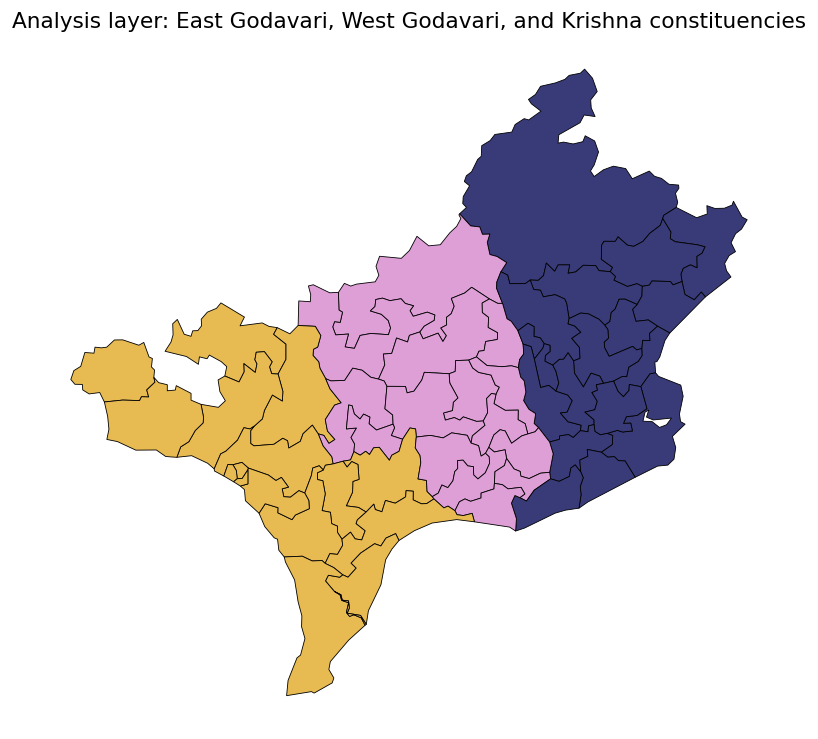

In [5]:
plot_layer(
    districts,
    "DIST_NAME",
    "Analysis layer: East Godavari, West Godavari, and Krishna constituencies",
    cmap="tab20b",
    focus_bounds=study_bounds,
)

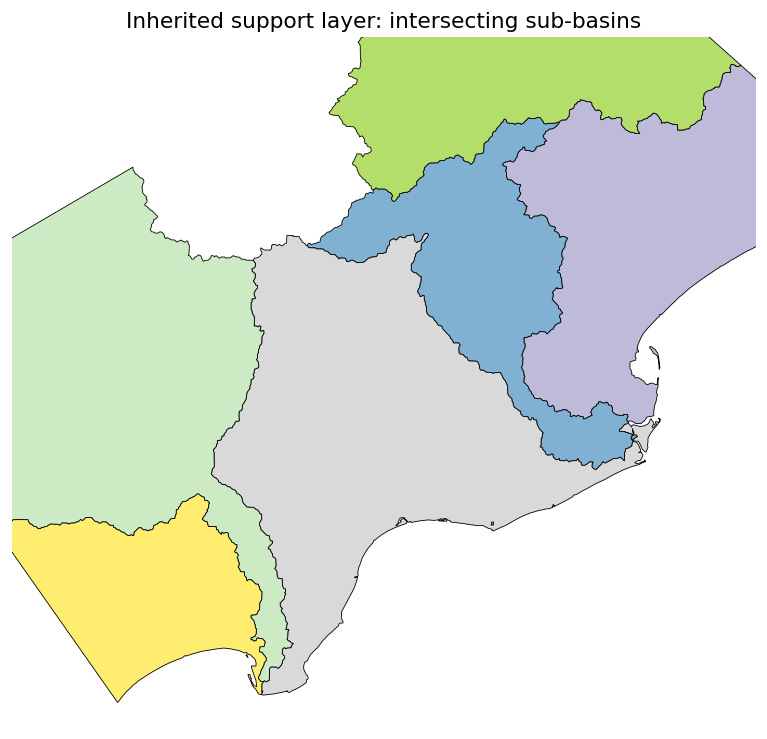

In [6]:
plot_layer(
    supports,
    "support_id",
    "Inherited support layer: intersecting sub-basins",
    cmap="Set3",
    focus_bounds=study_bounds,
)

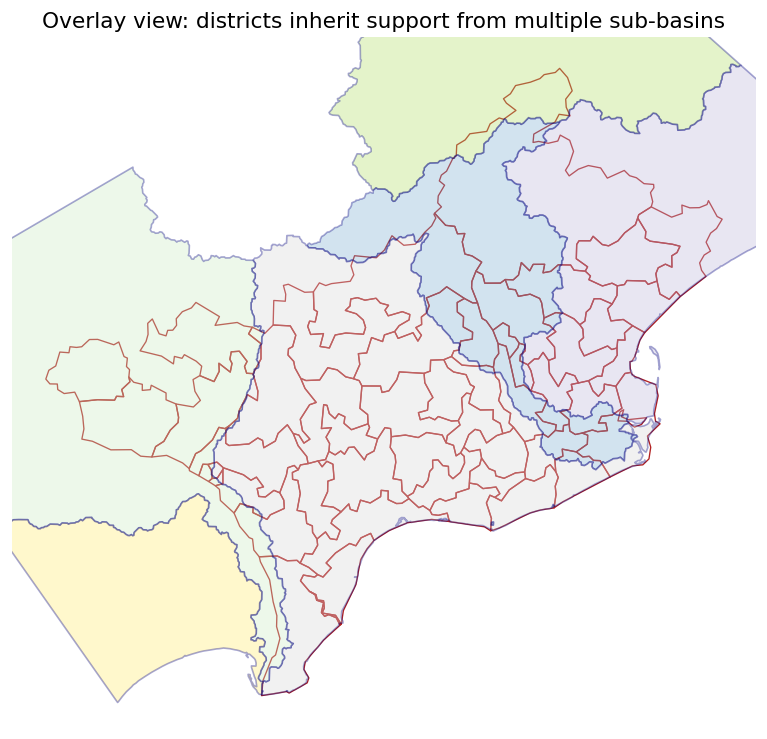

In [7]:
ax = districts.plot(facecolor="none", edgecolor="firebrick", linewidth=0.8)
supports.plot(ax=ax, column="support_id", cmap="Set3", alpha=0.35, edgecolor="navy", linewidth=1.0)
minx, miny, maxx, maxy = study_bounds
padx = 0.05 * (maxx - minx)
pady = 0.05 * (maxy - miny)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_title("Overlay view: districts inherit support from multiple sub-basins")
ax.set_axis_off()
plt.show()

The overlay view is the geometric foundation of the operator. Two districts can become related in RelWeights if they intersect the same support polygon, even if a simple same-layer contiguity rule would not connect them strongly.

In [8]:
interactive_map = districts.explore(
    column="DIST_NAME",
    cmap="tab20b",
    tooltip=["ac_id", "AC_NAME", "DIST_NAME"],
    popup=["ac_id", "AC_NAME", "DIST_NAME"],
    name="Districts",
    tiles="CartoDB positron",
    legend=False,
    show=True,
    style_kwds={"weight": 1.0, "fillOpacity": 0.45},
)

supports.explore(
    m=interactive_map,
    column="support_id",
    cmap="Set3",
    tooltip=["support_id", "pfaf_id"],
    popup=["support_id", "pfaf_id", "AreaSQKM_B"],
    name="Inherited supports",
    legend=False,
    show=True,
    style_kwds={"weight": 1.2, "fillOpacity": 0.25},
)

folium.LayerControl(collapsed=False).add_to(interactive_map)

save_and_embed_folium_map(
    interactive_map,
    interactive_dir / "overlay-support-map.html",
    height=560,
)

The interactive `explore()` map is now saved as a standalone HTML artifact before being embedded back into the notebook. That is more reliable than relying on the notebook renderer to interpret Folium objects directly, especially inside VS Code and MyST-derived notebook flows. The layer control still lets you toggle districts and inherited supports on and off, and the automatic legends are intentionally suppressed here because two categorical legends would overlap and clutter the map.

## Build the incidence matrices

In [9]:
B_bin, B_area, overlay = build_incidence_matrices(
    rel_layer=districts,
    inh_layer=supports,
    rel_id="ac_id",
    inh_id="support_id",
)

print("Binary incidence matrix shape:", B_bin.shape)
print("Area-share incidence matrix shape:", B_area.shape)
print()
print("First five rows of B_bin")
print(B_bin.head().to_string())
print()
print("First five rows of B_area")
print(B_area.head().round(3).to_string())

Binary incidence matrix shape: (50, 7)
Area-share incidence matrix shape: (50, 7)

First five rows of B_bin
support_id  SB_01  SB_02  SB_03  SB_04  SB_05  SB_06  SB_07
ac_id                                                      
AC_01           0      1      1      1      0      0      0
AC_02           0      1      0      0      0      0      0
AC_03           0      0      1      0      1      0      0
AC_04           0      1      0      0      0      0      0
AC_05           0      1      1      0      0      0      0

First five rows of B_area
support_id  SB_01  SB_02  SB_03  SB_04  SB_05  SB_06  SB_07
ac_id                                                      
AC_01         0.0  0.395  0.472  0.133  0.000    0.0    0.0
AC_02         0.0  0.996  0.000  0.000  0.000    0.0    0.0
AC_03         0.0  0.000  0.363  0.000  0.637    0.0    0.0
AC_04         0.0  1.000  0.000  0.000  0.000    0.0    0.0
AC_05         0.0  0.561  0.439  0.000  0.000    0.0    0.0


The two matrices encode different modeling choices:

- `B_bin` keeps only support presence/absence
- `B_area` records how much of each district is carried by each support polygon

The public `relweights.py` script uses the binary form by default when it turns positive intersections into a weight object. Here we inspect both versions before committing to one.

In [10]:
row_share_sums = B_area.sum(axis=1)
print("Area-share row sums (should be close to 1 when supports partition the district extent they cover):")
print(row_share_sums.round(4).head(10).to_string())

Area-share row sums (should be close to 1 when supports partition the district extent they cover):
ac_id
AC_01    1.0000
AC_02    0.9962
AC_03    1.0000
AC_04    1.0000
AC_05    1.0000
AC_06    1.0000
AC_07    0.9811
AC_08    1.0000
AC_09    1.0000
AC_10    1.0000


## Construct the RelWeights matrix

In [11]:
R_binary = relweights_from_incidence(B_bin, row_standardize=False)
R_binary_row = relweights_from_incidence(B_bin, row_standardize=True)

print("Top-left block of raw R from binary incidence")
print(R_binary.iloc[:8, :8].to_string())
print()
print("Top-left block of row-standardized R")
print(R_binary_row.iloc[:8, :8].round(3).to_string())

Top-left block of raw R from binary incidence
ac_id  AC_01  AC_02  AC_03  AC_04  AC_05  AC_06  AC_07  AC_08
ac_id                                                        
AC_01    0.0    1.0    1.0    1.0    2.0    2.0    1.0    0.0
AC_02    1.0    0.0    0.0    1.0    1.0    1.0    1.0    0.0
AC_03    1.0    0.0    0.0    0.0    1.0    1.0    0.0    1.0
AC_04    1.0    1.0    0.0    0.0    1.0    1.0    1.0    0.0
AC_05    2.0    1.0    1.0    1.0    0.0    2.0    1.0    0.0
AC_06    2.0    1.0    1.0    1.0    2.0    0.0    1.0    0.0
AC_07    1.0    1.0    0.0    1.0    1.0    1.0    0.0    0.0
AC_08    0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0

Top-left block of row-standardized R
ac_id  AC_01  AC_02  AC_03  AC_04  AC_05  AC_06  AC_07  AC_08
ac_id                                                        
AC_01  0.000  0.036  0.036  0.036  0.071  0.071  0.036   0.00
AC_02  0.077  0.000  0.000  0.077  0.077  0.077  0.077   0.00
AC_03  0.020  0.000  0.000  0.000  0.020  0.020 

This is the operational RelWeights step:

1. start from a cross-layer incidence matrix $B$
2. compute $B B^{\top}$ to measure shared inherited support
3. zero out the diagonal so that self-similarity does not dominate the graph

If two districts share more sub-basins, the corresponding entry of $R$ is larger.

## Compare contextual ties with geographic contiguity

In [12]:
GEOGRAPHIC_LABEL = GEOGRAPHIC_CONTIGUITY.title()
W_geo = build_geographic_contiguity_weights(
    districts,
    "ac_id",
    mode=GEOGRAPHIC_CONTIGUITY,
)
geo_column_name = f"{GEOGRAPHIC_CONTIGUITY}_degree"

print(f"Geographic contiguity baseline: {GEOGRAPHIC_LABEL}")

degree_compare = pd.DataFrame(
    {
        geo_column_name: W_geo.sum(axis=1),
        "rel_degree_raw": R_binary.sum(axis=1),
        "rel_degree_binary": (R_binary > 0).sum(axis=1),
    }
)

print(degree_compare.describe().round(2).to_string())

Geographic contiguity baseline: Queen
       queen_degree  rel_degree_raw  rel_degree_binary
count         50.00           50.00              50.00
mean           4.84           35.00              30.52
std            1.73           12.83              10.25
min            1.00           11.00              11.00
25%            4.00           28.00              20.00
50%            5.00           34.00              34.00
75%            6.00           45.00              36.00
max            8.00           62.00              47.00


In [13]:
example_id = degree_compare["rel_degree_raw"].sort_values(ascending=False).index[0]
example_neighbors = pd.DataFrame(
    {
        f"{GEOGRAPHIC_CONTIGUITY}_contiguity": W_geo.loc[example_id],
        "relweight_raw": R_binary.loc[example_id],
        "relweight_rowstd": R_binary_row.loc[example_id],
    }
)
example_neighbors = example_neighbors.query(f"{GEOGRAPHIC_CONTIGUITY}_contiguity > 0 or relweight_raw > 0")
print(f"Neighborhood structure for {example_id}")
print(example_neighbors.sort_values('relweight_raw', ascending=False).round(3).to_string())

Neighborhood structure for AC_20
       queen_contiguity  relweight_raw  relweight_rowstd
AC_19               0.0            3.0             0.048
AC_03               0.0            2.0             0.032
AC_01               0.0            2.0             0.032
AC_06               0.0            2.0             0.032
AC_13               0.0            2.0             0.032
AC_11               0.0            2.0             0.032
AC_05               0.0            2.0             0.032
AC_22               0.0            2.0             0.032
AC_37               1.0            2.0             0.032
AC_28               1.0            2.0             0.032
AC_32               1.0            2.0             0.032
AC_18               0.0            2.0             0.032
AC_24               0.0            2.0             0.032
AC_09               0.0            2.0             0.032
AC_07               0.0            1.0             0.016
AC_15               0.0            1.0             0.01

The notebook now defaults to **queen contiguity**, but the helper is explicit about the modeling choice. If you set `GEOGRAPHIC_CONTIGUITY = "rook"`, the same code reruns with shared-edge adjacency instead of shared-corner-or-edge adjacency. That makes the geographic baseline comparable across both common first-order contiguity conventions.

This comparison is the main conceptual payoff. A geographic weight matrix asks, "who is contiguous with me under the chosen same-layer rule?" A RelWeights matrix asks, "who inherits the same supports I inherit?" The two overlap, but they are not the same graph.

## Visualize the geographic graph and additional inherited ties

In [14]:
district_nodes = build_centroid_nodes(
    districts,
    id_col="ac_id",
    label_cols=["AC_NAME"],
)
R_indicator = (R_binary > 0).astype(float)
rel_only_indicator = ((R_indicator > 0) & (W_geo == 0)).astype(float)

geo_edges = build_centroid_edges(
    districts,
    id_col="ac_id",
    weights_df=W_geo,
    edge_type=f"{GEOGRAPHIC_CONTIGUITY}_contiguity",
)
rel_only_edges = build_centroid_edges(
    districts,
    id_col="ac_id",
    weights_df=rel_only_indicator,
    edge_type="relweights_only",
)

geo_edge_count = int(np.triu(W_geo.to_numpy(dtype=int), 1).sum())
rel_edge_count = int(np.triu(R_indicator.to_numpy(dtype=int), 1).sum())
rel_only_edge_count = int(np.triu(rel_only_indicator.to_numpy(dtype=int), 1).sum())

print(f"{GEOGRAPHIC_LABEL} edges: {geo_edge_count}")
print(f"RelWeights edges: {rel_edge_count}")
print(f"RelWeights-only inherited ties: {rel_only_edge_count}")

Queen edges: 121
RelWeights edges: 763
RelWeights-only inherited ties: 642


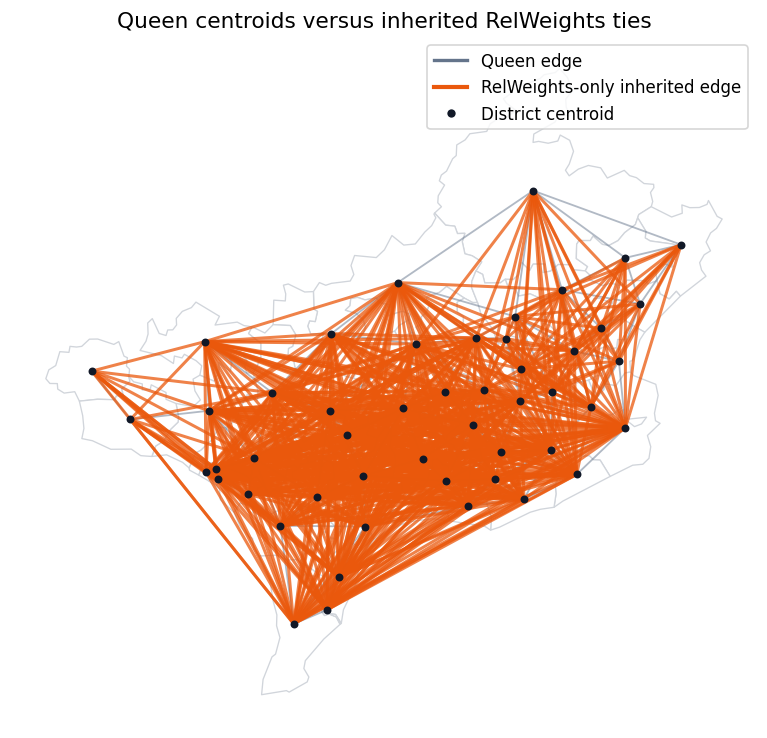

In [15]:
ax = districts.plot(facecolor="white", edgecolor="#d1d5db", linewidth=0.8)
if not geo_edges.empty:
    geo_edges.plot(ax=ax, color="#64748b", linewidth=1.1, alpha=0.5)
if not rel_only_edges.empty:
    rel_only_edges.plot(ax=ax, color="#ea580c", linewidth=1.8, alpha=0.75)
district_nodes.plot(ax=ax, color="#111827", markersize=14, zorder=3)

minx, miny, maxx, maxy = study_bounds
padx = 0.05 * (maxx - minx)
pady = 0.05 * (maxy - miny)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_title(f"{GEOGRAPHIC_LABEL} centroids versus inherited RelWeights ties")
ax.legend(
    handles=[
        Line2D([0], [0], color="#64748b", lw=2, label=f"{GEOGRAPHIC_LABEL} edge"),
        Line2D([0], [0], color="#ea580c", lw=2.5, label="RelWeights-only inherited edge"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#111827", markersize=6, label="District centroid"),
    ],
    loc="upper right",
    frameon=True,
)
ax.set_axis_off()
plt.show()

This graph view uses polygon centroids as nodes. Gray edges reproduce the chosen same-layer contiguity graph, while the orange lines isolate **additional inherited ties** that only appear after the overlay operator is built. Those orange ties are the empirical payoff of RelWeights: districts can become connected because they share contextual supports, not because they share a border.

In [16]:
connectivity_map = make_connectivity_map(
    districts=districts,
    centroid_nodes=district_nodes,
    geographic_edges=geo_edges,
    rel_only_edges=rel_only_edges,
    id_col="ac_id",
    label_col="AC_NAME",
    geographic_label=GEOGRAPHIC_LABEL,
)

save_and_embed_folium_map(
    connectivity_map,
    interactive_dir / f"{GEOGRAPHIC_CONTIGUITY}-vs-relweights-connectivity.html",
)

The layer-toggle map above is the cleanest way to inspect the full graph. You can switch the district polygons, centroid nodes, geographic edges, and RelWeights-only inherited ties on and off without leaving the notebook.

## Hover through geographic and RelWeights neighborhoods

In [17]:
queen_neighbor_map = make_hover_neighbor_map(
    districts=districts,
    centroid_nodes=district_nodes,
    weights_df=W_geo,
    id_col="ac_id",
    label_col="AC_NAME",
    title=f"{GEOGRAPHIC_LABEL} neighborhood explorer",
    neighbor_color="#2563eb",
    edge_color="#2563eb",
)

save_and_embed_folium_map(
    queen_neighbor_map,
    interactive_dir / f"{GEOGRAPHIC_CONTIGUITY}-neighbor-explorer.html",
)

In [18]:
rel_neighbor_map = make_hover_neighbor_map(
    districts=districts,
    centroid_nodes=district_nodes,
    weights_df=R_indicator,
    id_col="ac_id",
    label_col="AC_NAME",
    title="RelWeights neighborhood explorer",
    neighbor_color="#ea580c",
    edge_color="#ea580c",
)

save_and_embed_folium_map(
    rel_neighbor_map,
    interactive_dir / "relweights-neighbor-explorer.html",
)

In the geographic map, hovering a district reveals its first-order neighbors under the chosen contiguity rule. In the RelWeights map, hovering the same district reveals the irregular but non-arbitrary set of districts connected through shared inherited supports.

## Build the relational Laplacian

In [19]:
L_R = laplacian_from_weights(R_binary)
print("Top-left block of L_R")
print(L_R.iloc[:8, :8].to_string())

Top-left block of L_R
ac_id  AC_01  AC_02  AC_03  AC_04  AC_05  AC_06  AC_07  AC_08
ac_id                                                        
AC_01   28.0   -1.0   -1.0   -1.0   -2.0   -2.0   -1.0    0.0
AC_02   -1.0   13.0    0.0   -1.0   -1.0   -1.0   -1.0    0.0
AC_03   -1.0    0.0   49.0    0.0   -1.0   -1.0    0.0   -1.0
AC_04   -1.0   -1.0    0.0   13.0   -1.0   -1.0   -1.0    0.0
AC_05   -2.0   -1.0   -1.0   -1.0   28.0   -2.0   -1.0    0.0
AC_06   -2.0   -1.0   -1.0   -1.0   -2.0   28.0   -1.0    0.0
AC_07   -1.0   -1.0    0.0   -1.0   -1.0   -1.0   13.0    0.0
AC_08    0.0    0.0   -1.0    0.0    0.0    0.0    0.0   34.0


The Laplacian is the operator form of the graph. Once $R$ is built, the rest of the pipeline is standard:

$$
L_R = D_R - R.
$$

This is the object used for energies, smoothing, spectral decomposition, and contextual diagnostics.

## Compute a demonstration Laplacian energy

To keep the example transparent, we will use a simple east-west signal on the districts: the standardized projected x-coordinate of each district centroid.

In [ ]:
districts_proj = districts.to_crs(AREA_CRS).copy()
districts_proj["centroid_x"] = districts_proj.geometry.centroid.x

signal = (
    (districts_proj["centroid_x"] - districts_proj["centroid_x"].mean())
    / districts_proj["centroid_x"].std(ddof=0)
).to_numpy(dtype=float)
L_W = laplacian_from_weights(W_geo)
energy_R = centered_laplacian_energy(signal, L_R)
energy_W = centered_laplacian_energy(signal, L_W)

print(f"Centered Laplacian energy under contextual R: {energy_R:,.2f}")
print(f"Centered Laplacian energy under geographic {GEOGRAPHIC_LABEL.lower()} weights: {energy_W:,.2f}")

These two energies are not on the same normalization scale, so the comparison is not a formal test. But they do illustrate a useful idea:

- $z^{\top} L_W z$ measures roughness over geographic adjacency
- $z^{\top} L_R z$ measures roughness over inherited contextual support

The support graph changes the notion of what counts as "smooth."

## Generate a sub-basin surface

The centroid-x signal above was only a warm-up. For the main operator workflow, we now create a simple scalar field directly on the inherited sub-basin layer. Each sub-basin receives one deterministic effect, and that effect is then treated as a contextual surface that districts inherit through clipping and averaging.

In [ ]:
support_effects = build_support_effects(supports)
supports_surface = supports.merge(support_effects, on="support_id", how="left")

print("Support-level effects")
print(support_effects.round(3).to_string(index=False))

In [ ]:
plot_layer(
    supports_surface,
    "support_effect",
    "Sub-basin surface values before aggregation to districts",
    cmap="viridis",
    focus_bounds=study_bounds,
)

At this stage the surface still lives on the inherited support layer. The next step is to sample it densely over the study area and then average those values within each district.

## Sample and visualize the surface

In [ ]:
grid_points, surface_xx, surface_yy = make_surface_grid(districts, n_x=110, n_y=110)
surface_grid = assign_surface_to_grid(
    grid_points=grid_points,
    supports=supports,
    support_effects=support_effects,
    districts=districts,
)
surface_matrix = grid_to_surface_matrix(surface_grid, surface_xx, surface_yy)

print(f"Interior grid points used for discretization: {len(surface_grid):,}")
print("Support-count distribution at grid points")
print(surface_grid["support_count"].value_counts().sort_index().to_string())

In [ ]:
plot_surface_2d(
    surface_xx,
    surface_yy,
    surface_matrix,
    "Support-level surface sampled on a regular grid",
)

In [ ]:
plot_surface_3d(
    surface_xx,
    surface_yy,
    surface_matrix,
    "3D view of the inherited support surface",
)

Because the underlying values are attached to sub-basins, the surface is piecewise constant on those supports. The 3D plot makes that especially clear: the contextual field is built from inherited spatial supports rather than from same-layer geographic smoothing.

## Discretize the surface to district means

To move from the support layer back to the district layer, we approximate

$$
\bar{x}_i = \frac{1}{|A_i|}\int_{A_i} x(s)\,ds
$$

by taking the mean of the gridded surface values that fall inside district $i$. This is the numerical version of clipping the surface to each district and averaging over the clipped area.

In [ ]:
district_surface_mean = aggregate_surface_to_districts(
    surface_grid,
    districts,
    value_col="support_effect",
).fillna(0.0)

district_signal = pd.DataFrame(
    {
        "ac_id": districts["ac_id"],
        "surface_mean": district_surface_mean.to_numpy(dtype=float),
    }
)

print("District-level surface summary")
print(district_signal["surface_mean"].describe().round(3).to_string())

In [ ]:
plot_district_signal(
    districts,
    district_signal,
    "surface_mean",
    "District means obtained by clipping and averaging the support surface",
    cmap="viridis",
)

This district map is the discretized signal that we will now push through both the geographic Laplacian and the RelWeights Laplacian.

## Run the linear Laplacian form on the discretized signal

In [ ]:
district_surface_values = district_surface_mean.to_numpy(dtype=float)
linear_response_W = linear_laplacian_response(district_surface_values, L_W, center=True)
linear_response_R = linear_laplacian_response(district_surface_values, L_R, center=True)

linear_response_df = pd.DataFrame(
    {
        "ac_id": districts["ac_id"],
        f"linear_{GEOGRAPHIC_CONTIGUITY}": linear_response_W,
        "linear_relweights": linear_response_R,
    }
)

print("First ten district-level linear responses")
print(linear_response_df.head(10).round(3).to_string(index=False))

In [ ]:
plot_district_signal(
    districts,
    linear_response_df,
    f"linear_{GEOGRAPHIC_CONTIGUITY}",
    f"Linear Laplacian response under {GEOGRAPHIC_LABEL} contiguity",
    cmap="coolwarm",
)

In [ ]:
plot_district_signal(
    districts,
    linear_response_df,
    "linear_relweights",
    "Linear Laplacian response under RelWeights",
    cmap="coolwarm",
)

The linear form $Lx$ is a district-by-district imbalance diagnostic. Positive values indicate districts whose surface mean sits above the corresponding weighted neighborhood average; negative values indicate districts below that neighborhood average.

## Run the quadratic Laplacian form on the discretized signal

In [ ]:
z_surface = district_surface_values - district_surface_values.mean()

quadratic_W_matrix = centered_laplacian_energy(district_surface_values, L_W)
quadratic_R_matrix = centered_laplacian_energy(district_surface_values, L_R)
quadratic_W_linear = float(z_surface @ linear_response_W)
quadratic_R_linear = float(z_surface @ linear_response_R)
quadratic_W_identity = quadratic_identity_from_weights(district_surface_values, W_geo)
quadratic_R_identity = quadratic_identity_from_weights(district_surface_values, R_binary)

quadratic_summary = pd.DataFrame(
    {
        "operator": [GEOGRAPHIC_LABEL, "RelWeights"],
        "z' L z": [quadratic_W_matrix, quadratic_R_matrix],
        "z' (L z)": [quadratic_W_linear, quadratic_R_linear],
        "0.5 sum w_ij (z_i - z_j)^2": [quadratic_W_identity, quadratic_R_identity],
    }
)

print(quadratic_summary.round(4).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(
    quadratic_summary["operator"],
    quadratic_summary["z' L z"],
    color=["#2563eb", "#ea580c"],
    width=0.65,
)
ax.set_title("Quadratic Laplacian energy of the discretized district signal")
ax.set_ylabel("Energy")
ax.grid(axis="y", alpha=0.25)
plt.show()

The three columns in the summary should agree up to floating-point tolerance. That is the key identity:

$$
z^{\top} L z
=
z^{\top}(Lz)
=
\frac{1}{2}\sum_{i,j} w_{ij}(z_i-z_j)^2.
$$

The matrix product, the dot product of the centered signal with its linear Laplacian response, and the pairwise difference identity are all the same quadratic energy written three different ways.

## Compute and visualize the eigenvalue spectra

In [ ]:
eigvals_W = np.linalg.eigvalsh(L_W.to_numpy(dtype=float))
eigvals_R = np.linalg.eigvalsh(L_R.to_numpy(dtype=float))

eigen_summary = pd.DataFrame(
    {
        "operator": [GEOGRAPHIC_LABEL, "RelWeights"],
        "lambda_min": [eigvals_W.min(), eigvals_R.min()],
        "lambda_2": [np.sort(eigvals_W)[1], np.sort(eigvals_R)[1]],
        "lambda_max": [eigvals_W.max(), eigvals_R.max()],
        "near_zero_count": [
            int(np.sum(np.isclose(eigvals_W, 0.0, atol=1e-8))),
            int(np.sum(np.isclose(eigvals_R, 0.0, atol=1e-8))),
        ],
    }
)

print(eigen_summary.round(6).to_string(index=False))

In [ ]:
plot_eigen_spectrum(
    eigvals_W,
    f"Ordered eigenvalues of the {GEOGRAPHIC_LABEL} Laplacian",
    color="#2563eb",
)

In [ ]:
plot_eigen_spectrum(
    eigvals_R,
    "Ordered eigenvalues of the RelWeights Laplacian",
    color="#ea580c",
)

The eigenvalues summarize the geometry of the operator. Small eigenvalues correspond to smooth modes of variation under the chosen graph, while larger eigenvalues correspond to sharper oscillations. Comparing the two spectra shows directly how inherited supports change the notion of smoothness relative to first-order geographic contiguity.

## What this lab established

This notebook implemented the construction chain

$$
\text{overlay} \longrightarrow B \longrightarrow R \longrightarrow L_R
$$

using a real polygon overlay example derived from the RelWeights repository. It then pushed a support-level surface through the full operator workflow:

- generate a scalar field on the inherited sub-basin layer
- sample that surface and average it back to district means
- compare district-level linear and quadratic Laplacian responses under geographic and contextual graphs
- inspect the eigenvalue spectrum of each operator

The key takeaway is not only that RelWeights can be computed from real data, but that they define a different neighborhood concept, a different roughness operator, and a different spectral notion of smoothness from same-layer adjacency.

## Exercises

1. Replace `B_bin` with `B_area` in the RelWeights construction and compare the resulting degree distribution.
2. Change the sample to a different district subset and check how the density of $R$ changes.
3. Switch `GEOGRAPHIC_CONTIGUITY` between `"queen"` and `"rook"` and compare how the geographic baseline changes relative to the contextual graph.
4. Compute $R$ from two inherited support layers stacked side by side rather than one.
5. Choose a substantive district attribute and compare its geographic and contextual Laplacian energies.